# Gold fcc111 infinite slab

> Willem de Kleijne | March 17, 2026  
>
> Sample: Gold fcc111    

In [1]:
import abtem
import numpy as np
import matplotlib.pyplot as plt

## Gold Unitcell


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

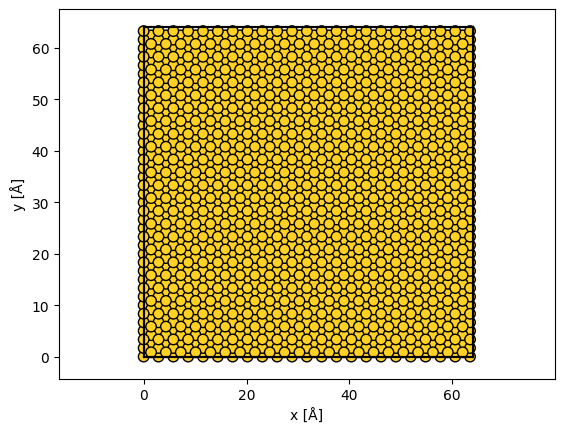

In [439]:
from ase.build import fcc111
lc=4.08
unit_cell =abtem.orthogonalize_cell( fcc111('Au', size=(2, 2, 3), a=lc, periodic=True,orthogonal=False))
super_cell = unit_cell * (12,7,1)
del super_cell[super_cell.positions[:,0] > 64]
del super_cell[super_cell.positions[:,1] > 64]
super_cell.cell[0,0] = 64
super_cell.cell[1,1] = 64 # make the cells square
abtem.show_atoms(super_cell)

## Potential

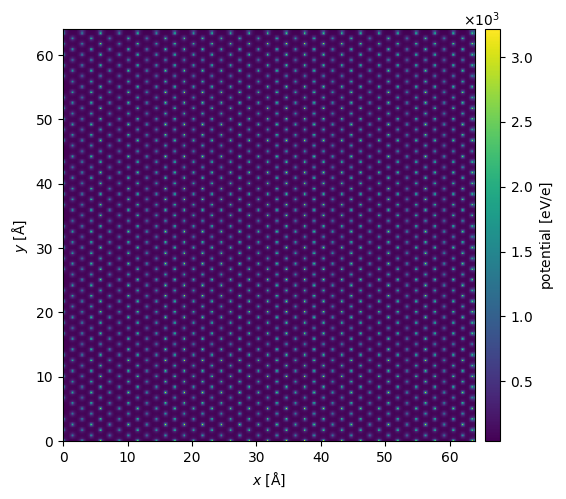

In [440]:
potential = abtem.Potential(
    super_cell,
    gpts=(512,512),         # to ensure that the size of diffraction pattern is 512x512
    slice_thickness= lc/8,
    device='cpu',
).build(
    lazy=False
)

potential.show(
    cbar=True
);

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

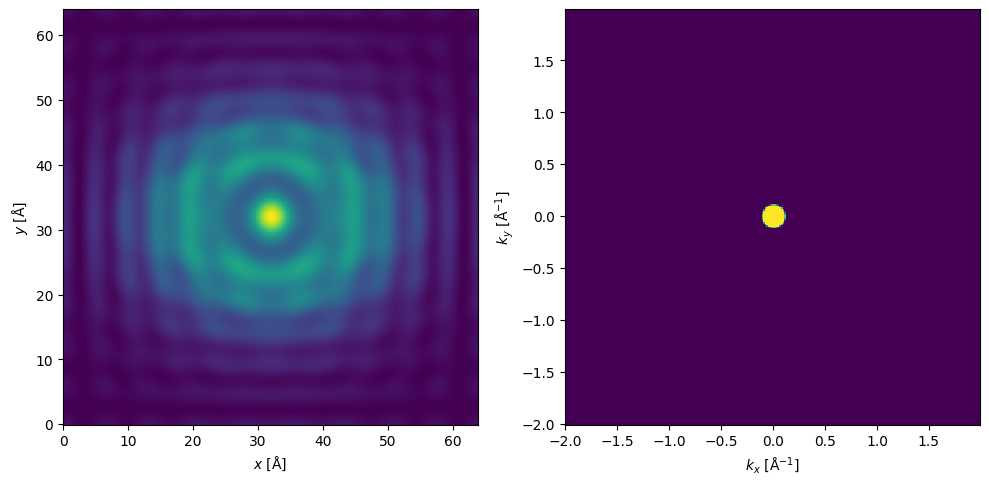

In [441]:
energy = 5e3 # eV
semiangle_cutoff = 20 # mrad


aberrations = {
    "C10":1000,
    "C12":100,
    "C30":1000000,
    "C21":100
    
}

probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

fig, axs = plt.subplots(1,2,figsize=(10,5))
probes.show(ax=axs[0])
probes.build().diffraction_patterns(max_angle=None).crop(gpts=(256,256)).show(ax=axs[1])
fig.tight_layout()

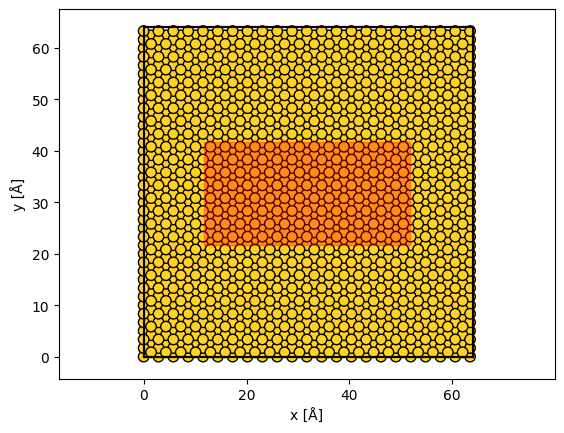

In [442]:
pos = super_cell.positions

x_extent = pos[:, 0].max() - pos[:, 0].min()
y_extent = pos[:, 1].max() - pos[:, 1].min()
gpt_x, gpt_y = 48+1, 24+1
grid_scan = abtem.GridScan(
    start = (x_extent/2-20, y_extent/2-10),
    end = (x_extent/2+20, y_extent/2+10),
    gpts=(gpt_x, gpt_y),
    endpoint=True
)

fig,ax = plt.subplots()
abtem.show_atoms(super_cell,ax=ax)
grid_scan.add_to_plot(ax)

detector = abtem.PixelatedDetector(
    max_angle=None
)

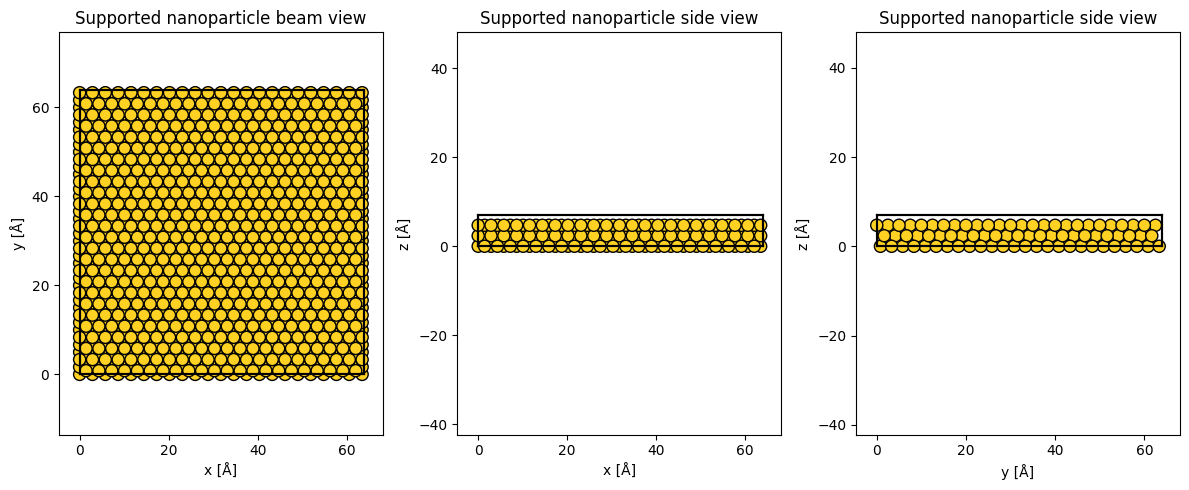

In [443]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    super_cell ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    super_cell ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    super_cell ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

In [444]:
detector = abtem.PixelatedDetector(max_angle='full')  # or 'full'
waves_detector = abtem.WavesDetector(
    
)

measurement, waves_measurement = probes.scan(
    potential,
    grid_scan,
    [detector, waves_detector],
).compute()

print(measurement.sampling)
print(waves_measurement.sampling)

tasks:   0%|          | 0/87 [00:00<?, ?it/s]

(0.015625, 0.015625)
(0.125, 0.125)


In [445]:
print(measurement.metadata)
print(waves_measurement.extent)

{'energy': 5000.0, 'semiangle_cutoff': 20, 'base_tilt_x': 0.0, 'base_tilt_y': 0.0, 'reciprocal_space': False, 'label': 'intensity', 'units': 'arb. unit'}
(64.0, 64.0)


In [446]:
waves_k_space = np.fft.fft2(np.fft.ifftshift(waves_measurement.array, axes=(-2, -1)), axes=(-2, -1))
waves_k_space_shifted = np.fft.fftshift(waves_k_space, axes=(-2, -1))

intensity_from_waves = np.abs(waves_k_space_shifted)**2



In [447]:
probe_array= probes.build().compute().array
print(probe_array.shape)


tasks:   0%|          | 0/2 [00:00<?, ?it/s]

(512, 512)


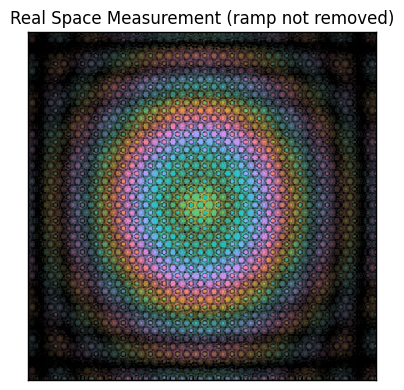

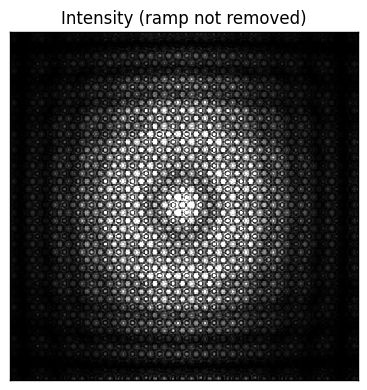

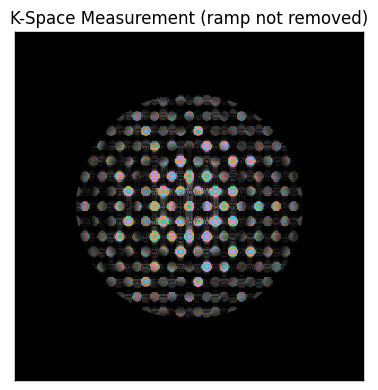

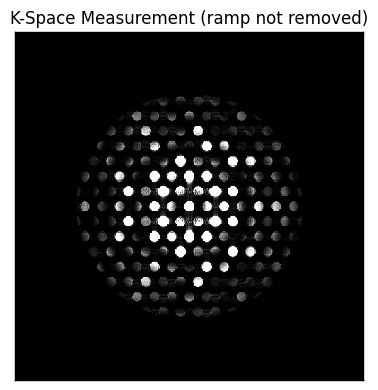

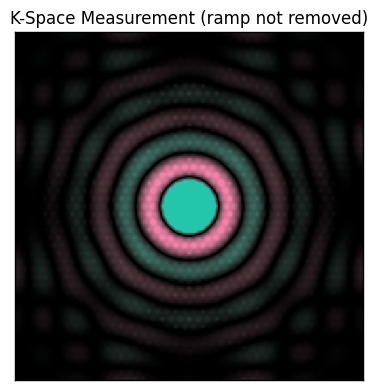

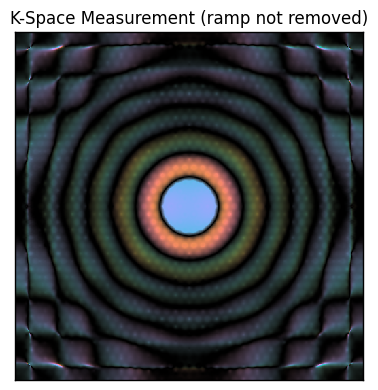

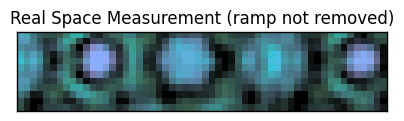

a


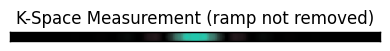

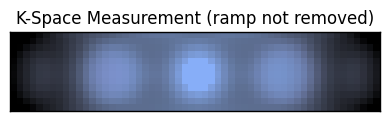

b


/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


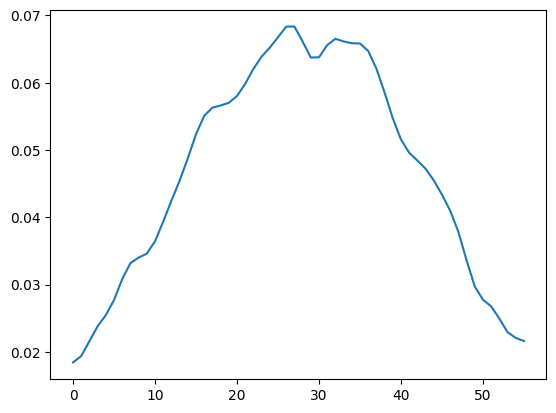

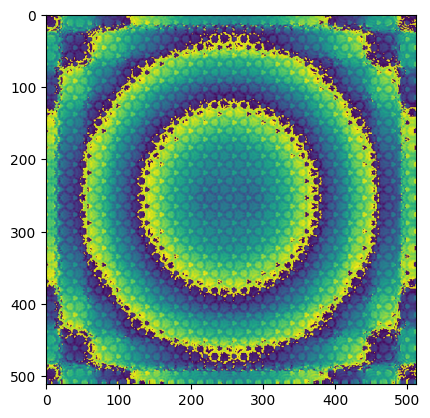

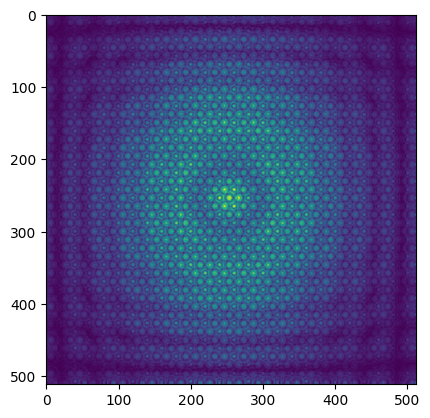

In [448]:

from quantem.core.visualization import show_2d
show_2d(waves_measurement.array[24,12], title="Real Space Measurement (ramp not removed)")
show_2d(abs(waves_measurement.array[24,12])**2, title="Intensity (ramp not removed)")
show_2d(waves_k_space_shifted[24,12], title="K-Space Measurement (ramp not removed)")
show_2d(abs(waves_k_space_shifted[24,12])**2, title="K-Space Measurement (ramp not removed)")
show_2d(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(abs(waves_k_space_shifted[24,12])**2))), title="K-Space Measurement (ramp not removed)")
show_2d(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(abs(waves_k_space_shifted[24,12])**2)))/probe_array, title="K-Space Measurement (ramp not removed)")
show_2d(waves_measurement.array[24,12][250:262,228:284]/probe_array[250:262,228:284], title="Real Space Measurement (ramp not removed)")
plt.show()
print('a')
show_2d(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(abs(waves_k_space_shifted[24,12])**2)))[250:262,:], title="K-Space Measurement (ramp not removed)")
show_2d(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(abs(waves_k_space_shifted[24,12])**2)))[250:262,228:284]/probe_array[250:262,228:284], title="K-Space Measurement (ramp not removed)")
plt.show()
print('b')
plt.plot(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(abs(waves_k_space_shifted[24,12])**2)))[250,228:284]/probe_array[250,228:284])
plt.show()
plt.imshow(np.angle(waves_measurement.array[24,12]))
plt.show()
plt.imshow(np.abs(waves_measurement.array[24,12]))
plt.show()

In [285]:
dx = waves_measurement.axes_metadata[-1].sampling  # real space sampling in Å/pixel
H, W = 512, 512


# remove phase ramp
fy = np.fft.fftfreq(H)  # (H,)
fx = np.fft.fftfreq(W)  # (W,)

# scan positions in Å from axes_metadata
x_coords = np.array(waves_measurement.axes_metadata[0].coordinates(49))  # shape (49,)
y_coords = np.array(waves_measurement.axes_metadata[1].coordinates(25))  # shape (25,)

r = x_coords[:, None] / dx          # (49, 1)
c = y_coords[None, :] / dx          # (1, 25)

phase_ramp = np.exp(-2j * np.pi * (
    r[:, :, None, None] * fy[None, None, :, None] +
    c[:, :, None, None] * fx[None, None, None, :]
))  # (49, 25, H, W)

waves = np.fft.ifftshift(waves_measurement.array, axes=(-2, -1))
waves_k = np.fft.fft2(waves, axes=(-2, -1))
waves_k_corrected_all = np.fft.fftshift(waves_k * phase_ramp, axes=(-2, -1))
waves_k_flat = waves_k_corrected_all.reshape(49 * 25, H, W)

In [289]:
kx = np.array(measurement.axes_metadata[-2].coordinates(H))  # 1/Å, shape (H,)
ky = np.array(measurement.axes_metadata[-1].coordinates(W))  # 1/Å, shape (W,)

x_coords = np.array(waves_measurement.axes_metadata[0].coordinates(49))  # Å, shape (49,)
y_coords = np.array(waves_measurement.axes_metadata[1].coordinates(25))  # Å, shape (25,)

# x_coords in Å * kx in 1/Å = dimensionless, correct!
phase_ramp = np.exp(-2j * np.pi * (
    x_coords[:, None, None, None] * kx[None, None, :, None] +
    y_coords[None, :, None, None] * ky[None, None, None, :]
))  # (49, 25, H, W)

waves = np.fft.ifftshift(waves_measurement.array, axes=(-2, -1))
waves_k = np.fft.fft2(waves, axes=(-2, -1))
waves_k_corrected_all = np.fft.fftshift(waves_k * phase_ramp, axes=(-2, -1))
waves_k_flat = waves_k_corrected_all.reshape(49 * 25, H, W)

In [286]:
waves_k_space_shifted_flat = waves_k_space_shifted.reshape(49 * 25, H, W)
print(dx)


0.125


(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'Ground Truth (ramp not removed)'}>)

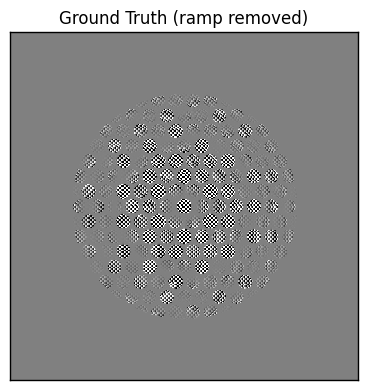

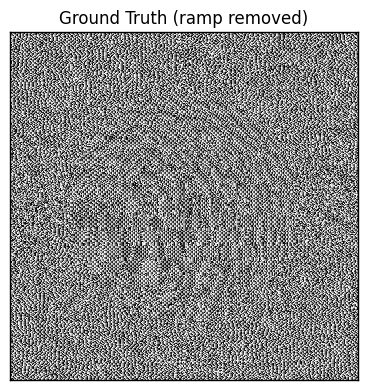

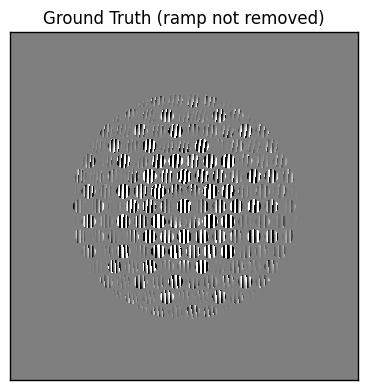

In [291]:
test = 600
test_ix, test_iy = test // 25, test % 25
show_2d(np.angle(waves_k_flat[test]) * np.abs(waves_k_flat[test])**2 / np.max(np.abs(waves_k_flat[test])**2), 
        title="Ground Truth (ramp removed)")

show_2d(np.angle(waves_k_flat[test]), 
        title="Ground Truth (ramp removed)")

show_2d(np.angle(waves_k_space_shifted_flat[test]) * np.abs(waves_k_space_shifted_flat[test])**2 / np.max(np.abs(waves_k_space_shifted_flat[test])**2), 
        title="Ground Truth (ramp not removed)")

In [256]:
print(waves_measurement.array.shape)
print(grid_scan)  # or print(grid_scan.start, grid_scan.end, grid_scan.sampling)
print(waves_measurement.axes_metadata)

(49, 25, 512, 512)
type           label    coordinates
-------------  -------  ---------------------
ScanAxis       x [Å]    11.73 12.57 ... 51.73
ScanAxis       y [Å]    21.65 22.48 ... 41.65
RealSpaceAxis  x [Å]    0.00 0.02 ... 7.98
RealSpaceAxis  y [Å]    0.00 0.02 ... 7.98


## According to metadata they should both be in real space but in the plot you can clearly say the intensity is different

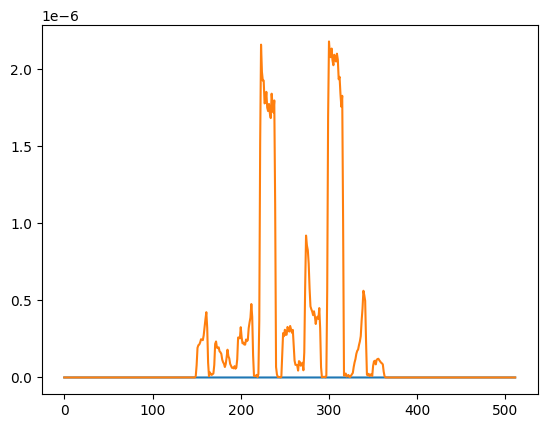

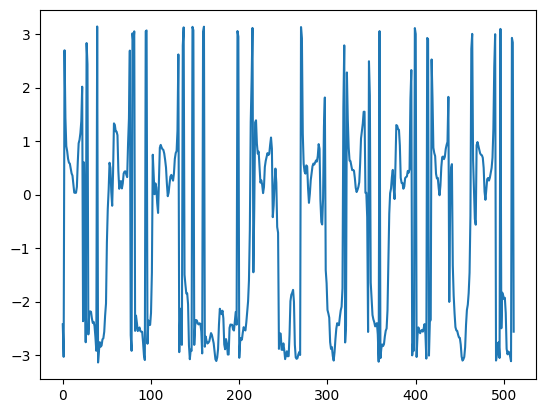

In [246]:
plt.plot(np.abs(waves_measurement.array[0, 0, 128, :])**2)
plt.plot(measurement.array[0, 0][128, :])
plt.show()
plt.plot(np.angle(waves_measurement.array[0, 0, 128, :]))
plt.show()


## If we now Fourier transform and shift the wave we see a perfect match

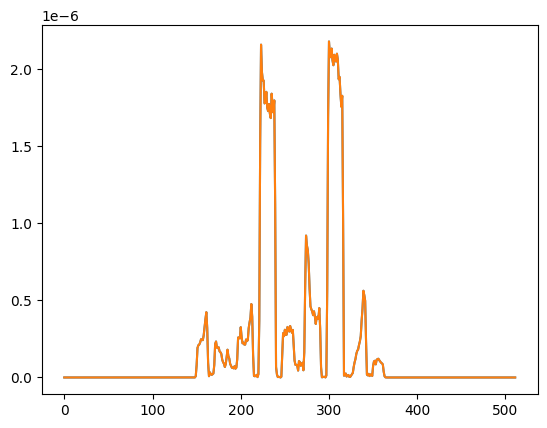

In [247]:
plt.plot(intensity_from_waves[0, 0, 128, :])
plt.plot(measurement.array[0, 0][128, :])
plt.show()

In [248]:
waves_measurement.array = waves_k_space_shifted
waves_measurement.sampling = measurement.sampling
waves_measurement.sampling

(0.015625, 0.015625)

In [249]:
dose = 1e7
measurement_noisy = measurement.crop(gpts=(256,256)).poisson_noise(dose)
measurement

In [250]:
dataset_noisy = measurement_noisy.to_quantem()
dataset_noisy.sampling

array([0.83333333, 0.83333333, 0.015625  , 0.015625  ])

## The wave object has no crop so we need to crop the array manually

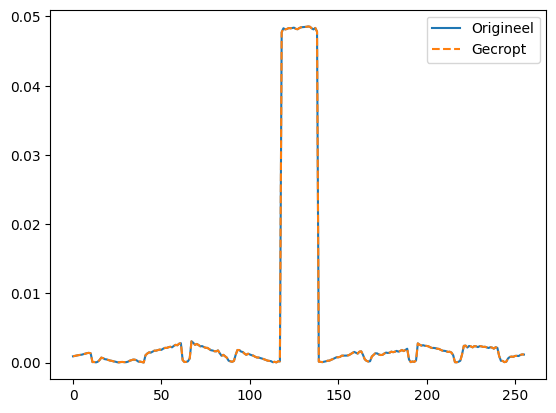

In [251]:
import abtem
import numpy as np

def crop_waves_object(waves_obj, new_gpts=(256, 256)):
    # 1. Bereken de indices (gaat uit van vierkante gpts als het een getal is)
    old_gpts = waves_obj.gpts
    start_y = (old_gpts[0] - new_gpts[0]) // 2
    start_x = (old_gpts[1] - new_gpts[1]) // 2
    
    # 2. Snij de array bij (behoudt de eerste scan-dimensies met ...)
    cropped_array = waves_obj.array[..., start_y:start_y+new_gpts[0], start_x:start_x+new_gpts[1]]
    
    # 3. Bereken de nieuwe 'extent'
    new_extent = (new_gpts[0] * waves_obj.sampling[0], 
                  new_gpts[1] * waves_obj.sampling[1])
    
    # 4. Maak een nieuw Waves object met ENSEMBLE metadata
    # De ensemble_axes_metadata bevat de informatie over je grid_scan (x, y posities)
    new_waves = abtem.Waves(
        array=cropped_array,
        sampling=waves_obj.sampling,
        energy=waves_obj.energy,
        extent=new_extent,
        ensemble_axes_metadata=waves_obj.ensemble_axes_metadata # DIT IS DE FIX
    )
    return new_waves, start_y, start_x

# Gebruik de functie
waves_cropped_obj, offset_y, offset_x = crop_waves_object(waves_measurement, (256, 256))

# --- Verificatie Plot ---
import matplotlib.pyplot as plt

# We vergelijken het midden van de crop (index 128) 
# met de corresponderende pixel in het origineel (128 + offset)
idx = 128 
plt.plot(np.abs(waves_measurement.array[0, 0, offset_y + idx, offset_x:offset_x+256]), label='Origineel')
plt.plot(np.abs(waves_cropped_obj.array[0, 0, idx, :]), label='Gecropt', linestyle='--')
plt.legend()
plt.show()


In [252]:
print(waves_cropped_obj)
print(waves_cropped_obj.axes_metadata)
waves_cropped_obj = waves_cropped_obj.to_quantem()

type           label    coordinates
-------------  -------  ---------------------
ScanAxis       x [Å]    11.73 12.57 ... 51.73
ScanAxis       y [Å]    21.65 22.48 ... 41.65
RealSpaceAxis  x [Å]    0.00 0.02 ... 3.98
RealSpaceAxis  y [Å]    0.00 0.02 ... 3.98


In [253]:
# print(dataset_noisy.extent)
waves_cropped_obj.units[-2:]= dataset_noisy.units[-2:]
waves_cropped_obj

Dataset(shape=(49, 25, 256, 256), dtype=complex64, name='Waves')
  sampling: [0.83333333 0.83333333 0.015625   0.015625  ]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'

In [254]:
dataset_noisy.save(f"/home/wdekleijne/git-repos/willem-playground/data/crystalline_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_{dose:.0e}-dose_gpts_{gpt_x}_{gpt_y}_3_layer_256x256.zip",mode='o')


In [255]:
waves_cropped_obj.save(f"/home/wdekleijne/git-repos/willem-playground/data/crystalline_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_{dose:.0e}-dose_gpts_{gpt_x}_{gpt_y}_3_layer_256x256_full_wave.zip",mode='o')
